 ## Khởi tạo Môi trường Tính toán



 Các lệnh dưới đây thiết lập các thư viện cốt lõi và cấu hình hỗ trợ biên dịch định dạng LaTeX cho hệ thống, đảm bảo chất lượng hiển thị chuẩn học thuật cho các đồ thị trực quan hóa.

In [13]:
!pip install pandas numpy matplotlib scipy uncertainties statsmodels sympy
!sudo apt-get install -y dvipng texlive-latex-extra texlive-fonts-recommended cm-super


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-1.1).
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-latex-extra is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


 ### 1. Tiền xử lý Dữ liệu Thực nghiệm và Trực quan hóa



 Quy trình thuật toán thực thi việc nạp dữ liệu định dạng cục bộ. Hệ thống được tinh chỉnh nhằm phân tích đặc tính động học của vật thể rơi tự do. Dữ liệu thời gian và độ dịch chuyển được biểu diễn dưới cấu trúc mảng. Vận tốc tức thời được suy xuất trực tiếp thông qua phương pháp vi phân số học (numerical differentiation).



 Tham chiếu: Chương 1, Tài liệu Tham chiếu.

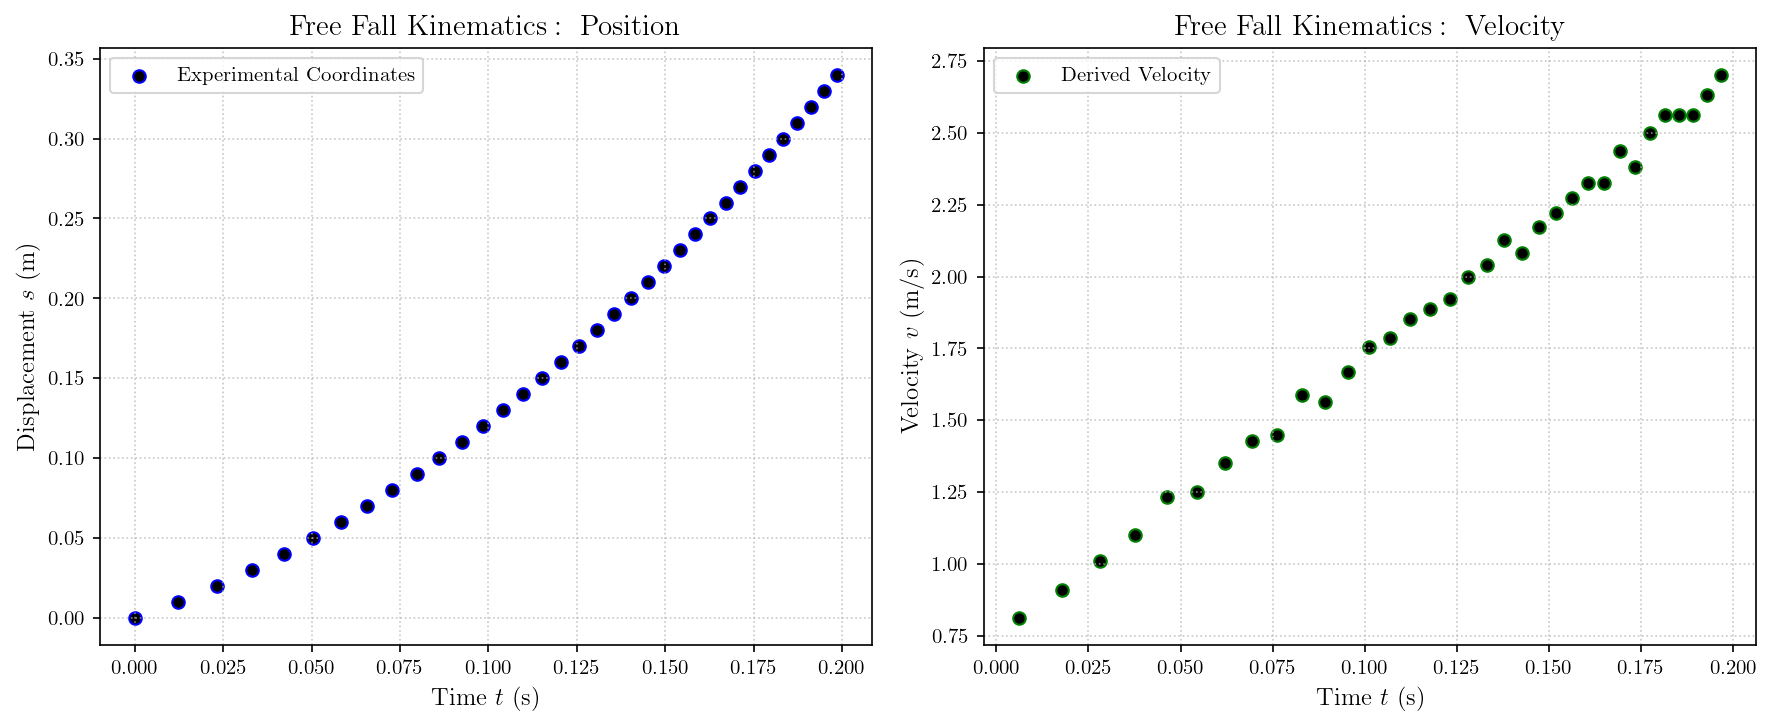

In [43]:
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt

# Global configuration for high-resolution scientific plotting
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "figure.dpi": 150,
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 14,
    "lines.linewidth": 1.5,
    "grid.alpha": 0.5,
    "grid.linestyle": "--"
})

# 1. Load Raw Data
df = pd.read_csv('kinematics_data.csv')
time_data = df['Time_s'].values
displacement_data = df['Displacement_m'].values

# Perform numerical differentiation to approximate instantaneous velocity: v = (s_i+1 - s_i) / (t_i+1 - t_i)
delta_s = np.diff(displacement_data)
delta_t = np.diff(time_data)
velocity_data = delta_s / delta_t

# Compute corresponding mid-point times for the derived velocity array
time_midpoints = time_data[:-1] + delta_t / 2.0

# Setup graphical structures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Visualization 1: Displacement vs Time
ax1.scatter(time_data, displacement_data, color='black', edgecolor='blue', label=r'$\mathrm{Experimental \ Coordinates}$')
ax1.set_xlabel(r'$\mathrm{Time} \ t \ (\mathrm{s})$')
ax1.set_ylabel(r'$\mathrm{Displacement} \ s \ (\mathrm{m})$')
ax1.set_title(r'$\mathrm{Free \ Fall \ Kinematics: \ Position}$')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)


# Visualization 2: Velocity vs Time
ax2.scatter(time_midpoints, velocity_data, color='black', edgecolor='green', label=r'$\mathrm{Derived \ Velocity}$')
ax2.set_xlabel(r'$\mathrm{Time} \ t \ (\mathrm{s})$')
ax2.set_ylabel(r'$\mathrm{Velocity} \ v \ (\mathrm{m/s})$')
ax2.set_title(r'$\mathrm{Free \ Fall \ Kinematics: \ Velocity}$')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


 ### 2. Lan truyền Sai số Giải tích và Tự động hóa



 Nguyên lý lan truyền độ bất định được áp dụng nhằm định lượng sai số tổng hợp cho các giá trị vận tốc tức thời. Khung tính toán khai triển các đạo hàm riêng biệt thông qua hệ thống đại số máy tính, đồng thời tích hợp thư viện chuyên dụng để duy trì cấu trúc sai số qua từng vòng lặp tính toán.



 Tham chiếu: Chương 2, Tài liệu Hướng dẫn Lý thuyết.

In [15]:
import sympy as sp
from uncertainties import unumpy as unp

# Define symbolic variables for the partial derivative extraction
s_i, s_j, t_i, t_j = sp.symbols('s_i s_j t_i t_j')
v_expr = (s_j - s_i) / (t_j - t_i)

# Automate partial derivative extraction to verify theoretical error propagation
print("Analytical Partial Derivative w.r.t final position (s_j):")
sp.pprint(sp.diff(v_expr, s_j))
print("\nAnalytical Partial Derivative w.r.t final time (t_j):")
sp.pprint(sp.diff(v_expr, t_j))
print("\n" + "="*50 + "\n")

# Assign standard instrumental uncertainties based on CASSY sensor limitations
sigma_s = 0.001   # Estimated spatial resolution: 1 mm
sigma_t = 0.0005  # Estimated temporal resolution: 0.5 ms

# Initialize uncertainty-bearing arrays
s_u = unp.uarray(displacement_data, sigma_s)
t_u = unp.uarray(time_data, sigma_t)

# Automate error propagation during numerical differentiation
ds_u = s_u[1:] - s_u[:-1]
dt_u = t_u[1:] - t_u[:-1]
v_u = ds_u / dt_u

# Extract nominal values and dynamically computed uncertainties
velocity_vals = unp.nominal_values(v_u)
velocity_errs = unp.std_devs(v_u)

print(f"Propagated Velocity Example [Index 5]: {v_u[5]:.4u} m/s")


Analytical Partial Derivative w.r.t final position (s_j):
    1    
─────────
-tᵢ + t_j

Analytical Partial Derivative w.r.t final time (t_j):
-(-sᵢ + s_j) 
─────────────
           2 
(-tᵢ + t_j)  


Propagated Velocity Example [Index 5]: 1.2500+/-0.2085 m/s


 ### 3. Hồi quy Động học và Ma trận Hiệp phương sai



 Thuật toán tối ưu hóa phi tuyến (đối với phương trình bậc hai của tọa độ) và tuyến tính (đối với vận tốc) được thực thi để xác định quỹ đạo rơi tự do. Gia tốc trọng trường được trích xuất như một thông số vật lý cốt lõi, đi kèm với độ lệch chuẩn ước lượng từ ma trận hiệp phương sai.



 Tham chiếu: Chương 3, Tài liệu Tham chiếu.

Gravitational Acceleration (Displacement Fit): 9.796 +/- 0.112 m/s^2
Gravitational Acceleration (Velocity Fit): 9.756 +/- 0.930 m/s^2
--------------------------------------------------
Explicit Kinematic Equations:
--------------------------------------------------
Position: s(t) = (4.898 +/- 0.056)t^2 + (0.737 +/- 0.012)t + (0.0002 +/- 0.0006)
Velocity: v(t) = (9.756 +/- 0.930)t + (0.742 +/- 0.078)
--------------------------------------------------



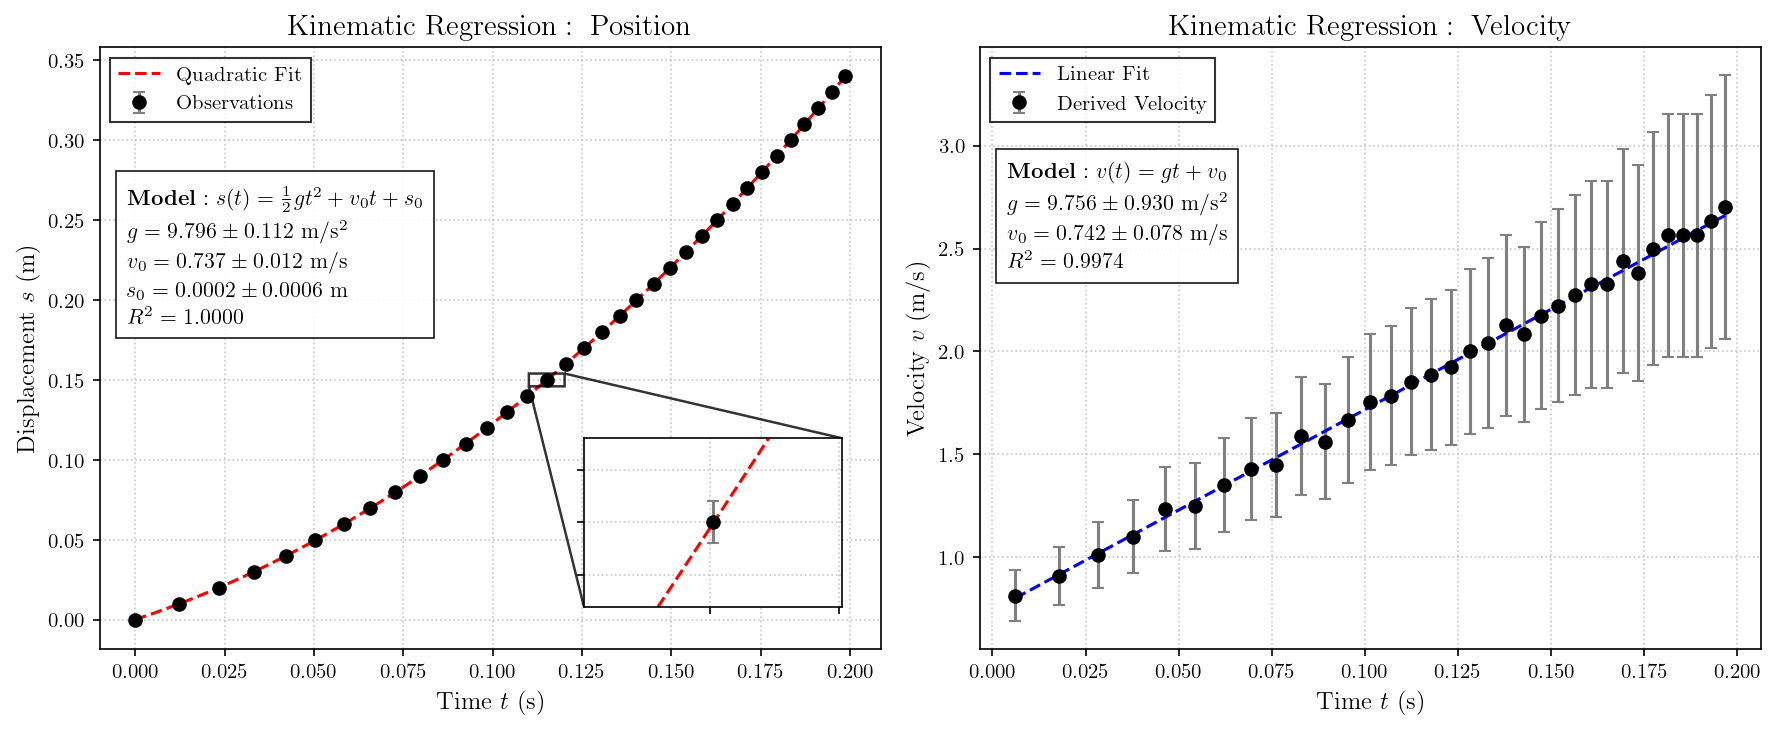

In [38]:
from scipy.optimize import curve_fit

# Define Theoretical Models for Free Fall Kinematics
def quadratic_displacement_model(t, g, v0, s0):
    # s(t) = 0.5 * g * t^2 + v0 * t + s0
    return 0.5 * g * t**2 + v0 * t + s0

def linear_velocity_model(t, g, v0):
    # v(t) = g * t + v0
    return g * t + v0

# Execute non-linear curve fitting for Displacement data
popt_s, pcov_s = curve_fit(
    quadratic_displacement_model,
    time_data,
    displacement_data,
    sigma=np.full_like(displacement_data, sigma_s),
    absolute_sigma=True,
    p0=[9.8, 0.0, 0.0]
)

# Extract optimized parameters and their absolute standard deviations

g_s_opt, v0_s_opt, s0_opt = popt_s
g_s_err, v0_s_err, s0_err = np.sqrt(np.diag(pcov_s))

coeff_A = 0.5 * g_s_opt
err_A   = 0.5 * g_s_err
# Execute linear curve fitting for Velocity data
popt_v, pcov_v = curve_fit(
    linear_velocity_model,
    time_midpoints,
    velocity_vals,
    sigma=velocity_errs,
    absolute_sigma=True,
    p0=[9.8, 0.0]
)


g_v_opt, v0_v_opt = popt_v
g_v_err, v0_v_err = np.sqrt(np.diag(pcov_v))

# R^2 for Displacement
ss_res_s = np.sum((displacement_data - quadratic_displacement_model(time_data, *popt_s))**2)
ss_tot_s = np.sum((displacement_data - np.mean(displacement_data))**2)
r2_s = 1 - (ss_res_s / ss_tot_s)

# R^2 for Velocity
ss_res_v = np.sum((velocity_vals - linear_velocity_model(time_midpoints, *popt_v))**2)
ss_tot_v = np.sum((velocity_vals - np.mean(velocity_vals))**2)
r2_v = 1 - (ss_res_v / ss_tot_v)

print(f"Gravitational Acceleration (Displacement Fit): {g_s_opt:.3f} +/- {g_s_err:.3f} m/s^2")
print(f"Gravitational Acceleration (Velocity Fit): {g_v_opt:.3f} +/- {g_v_err:.3f} m/s^2")

# ====================================================================
# 1. Console Output: Explicit Equations for Reporting
# ====================================================================
print("-" * 50)
print("Explicit Kinematic Equations:")
print("-" * 50)
# Note: coeff_A and err_A represent 1/2 * g and 1/2 * dg respectively
print(f"Position: s(t) = ({coeff_A:.3f} +/- {err_A:.3f})t^2 "
      f"+ ({v0_s_opt:.3f} +/- {v0_s_err:.3f})t "
      f"+ ({s0_opt:.4f} +/- {s0_err:.4f})")
print(f"Velocity: v(t) = ({g_v_opt:.3f} +/- {g_v_err:.3f})t "
      f"+ ({v0_v_opt:.3f} +/- {v0_v_err:.3f})")
print("-" * 50 + "\n")


# ====================================================================
# 2. Visual Configuration for Regression Models
# ====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Professional square box for parameters (OriginLab style)
param_box_props = dict(boxstyle='square,pad=0.5', facecolor='white',
                       alpha=0.9, edgecolor='black', linewidth=0.8)

# ---------------------------------------------------------
# Plot 1: Render Displacement Quadratic Regression
# ---------------------------------------------------------
t_fit_s = np.linspace(min(time_data), max(time_data), 200)

ax1.errorbar(time_data, displacement_data, yerr=sigma_s, fmt='o', color='black',
             ecolor='gray', capsize=3, label=r'$\mathrm{Observations}$')
ax1.plot(t_fit_s, quadratic_displacement_model(t_fit_s, *popt_s), 'r--',
         label=r'$\mathrm{Quadratic \ Fit}$')

# Standard notation: Defining the model first, parameters below
param_text_s = (
    r'$\mathbf{Model:}$ $s(t) = \frac{1}{2}gt^2 + v_0t + s_0$' + '\n' +
    fr'$g = {g_s_opt:.3f} \pm {g_s_err:.3f} \ \mathrm{{m/s^2}}$' + '\n' +
    fr'$v_0 = {v0_s_opt:.3f} \pm {v0_s_err:.3f} \ \mathrm{{m/s}}$' + '\n' +
    fr'$s_0 = {s0_opt:.4f} \pm {s0_err:.4f} \ \mathrm{{m}}$' + '\n' +
    fr'$R^2 = {r2_s:.4f}$'
)

# Compact Legend
ax1.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False)

# Parameter Box directly below the Legend
ax1.text(0.035, 0.77, param_text_s, transform=ax1.transAxes, fontsize=10.5,
         verticalalignment='top', linespacing=1.5, bbox=param_box_props)

ax1.set_xlabel(r'$\mathrm{Time} \ t \ (\mathrm{s})$')
ax1.set_ylabel(r'$\mathrm{Displacement} \ s \ (\mathrm{m})$')
ax1.set_title(r'$\mathrm{Kinematic \ Regression: \ Position}$')
ax1.grid(True, linestyle=':', alpha=0.7)

# --- Inset Axes for Position Plot ---
axins = ax1.inset_axes([0.62, 0.07, 0.33, 0.28])
axins.errorbar(time_data, displacement_data, yerr=sigma_s, fmt='o', color='black', ecolor='gray', capsize=3)
axins.plot(t_fit_s, quadratic_displacement_model(t_fit_s, *popt_s), 'r--')

zoom_t = time_data[15]
zoom_s = displacement_data[15]
axins.set_xlim(zoom_t - 0.005, zoom_t + 0.005)
axins.set_ylim(zoom_s - 0.004, zoom_s + 0.004)

axins.set_xticklabels([])
axins.set_yticklabels([])
axins.grid(True, linestyle=':', alpha=0.7)
ax1.indicate_inset_zoom(axins, edgecolor="black", linewidth=1.2, alpha=0.8)


# ---------------------------------------------------------
# Plot 2: Render Velocity Linear Regression
# ---------------------------------------------------------
t_fit_v = np.linspace(min(time_midpoints), max(time_midpoints), 200)

ax2.errorbar(time_midpoints, velocity_vals, yerr=velocity_errs, fmt='o', color='black',
             ecolor='gray', capsize=3, label=r'$\mathrm{Derived \ Velocity}$')
ax2.plot(t_fit_v, linear_velocity_model(t_fit_v, *popt_v), 'b--',
         label=r'$\mathrm{Linear \ Fit}$')

# Standard notation for Velocity
param_text_v = (
    r'$\mathbf{Model:}$ $v(t) = gt + v_0$' + '\n' +
    fr'$g = {g_v_opt:.3f} \pm {g_v_err:.3f} \ \mathrm{{m/s^2}}$' + '\n' +
    fr'$v_0 = {v0_v_opt:.3f} \pm {v0_v_err:.3f} \ \mathrm{{m/s}}$' + '\n' +
    fr'$R^2 = {r2_v:.4f}$'
)

ax2.legend(loc='upper left', frameon=True, edgecolor='black', fancybox=False)

# Parameter Box directly below the Legend
ax2.text(0.035, 0.81, param_text_v, transform=ax2.transAxes, fontsize=10.5,
         verticalalignment='top', linespacing=1.5, bbox=param_box_props)

ax2.set_xlabel(r'$\mathrm{Time} \ t \ (\mathrm{s})$')
ax2.set_ylabel(r'$\mathrm{Velocity} \ v \ (\mathrm{m/s})$')
ax2.set_title(r'$\mathrm{Kinematic \ Regression: \ Velocity}$')
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

 ### 4. Kỹ thuật Chẩn đoán Mô hình Nâng cao



 Các công cụ kiểm định thống kê được thiết lập nhằm chẩn đoán hệ thống một cách toàn diện. Giá trị Chi bình phương rút gọn xác thực sự tương thích của mô hình hồi quy. Kỹ thuật làm trơn LOWESS phân tích xu hướng ẩn trong cấu trúc phần dư đại số. Phân bố độ bất định của gia tốc được kiểm chứng chéo thông qua thuật toán mô phỏng Monte Carlo.



 Tham chiếu: Chương 4, Tài liệu Hướng dẫn Lý thuyết.

Reduced Chi-Square (Displacement Model): 0.0141


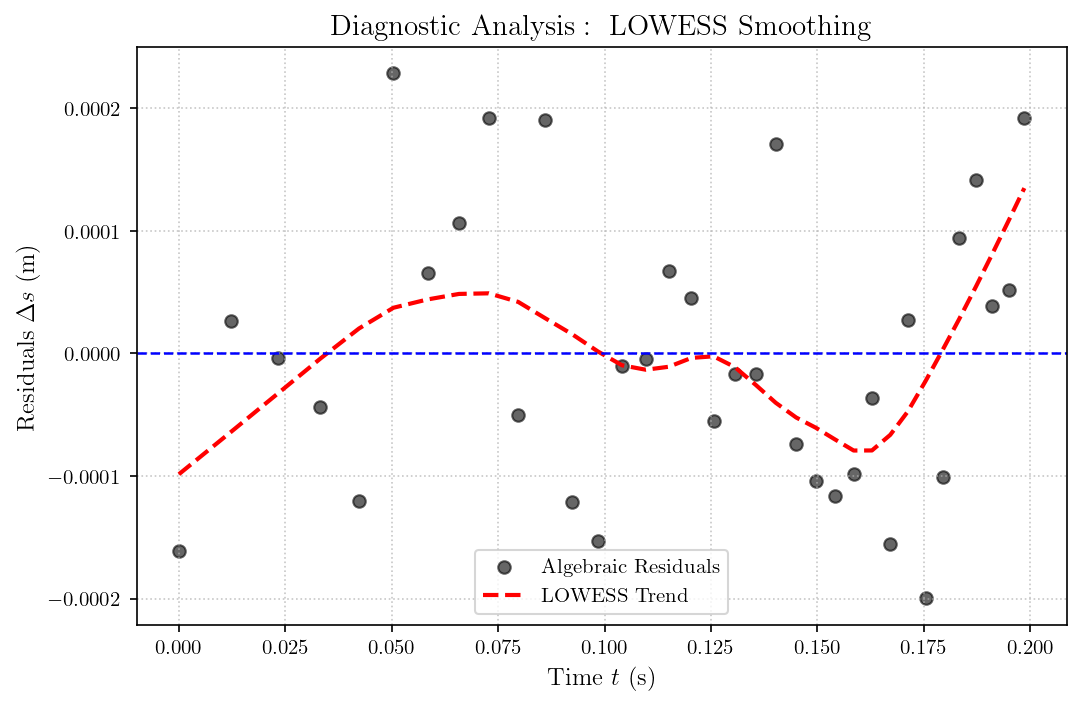

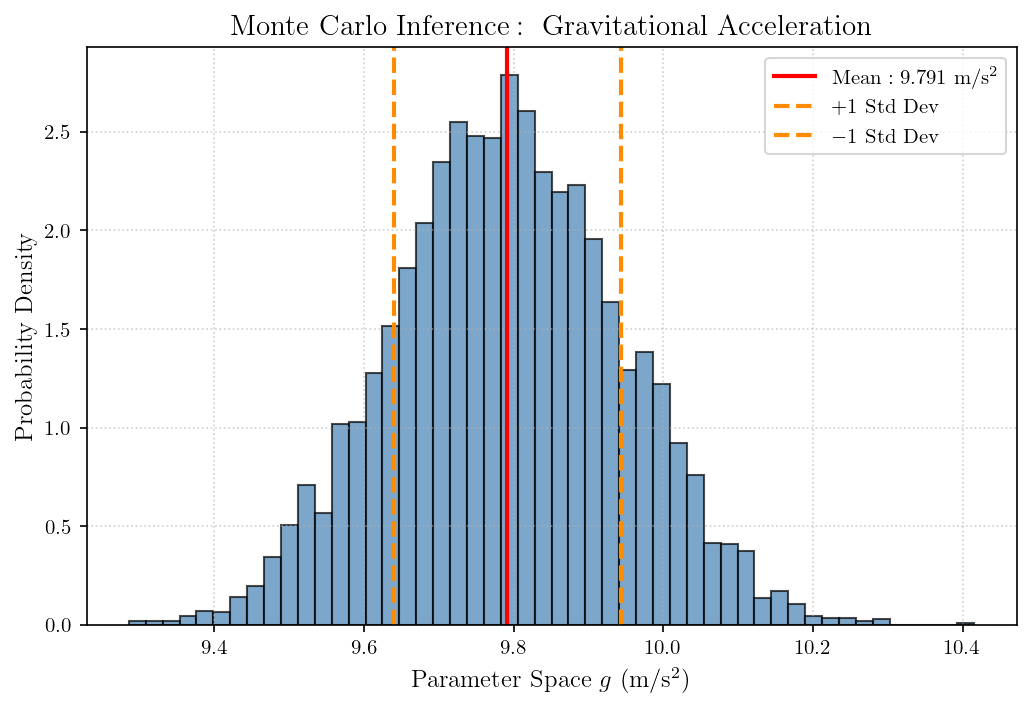

Monte Carlo Inference Result: g = 9.7915 +/- 0.1515 m/s^2


In [17]:
import statsmodels.api as sm

# 1. Implement Reduced Chi-Square Metric for the Displacement Model
residuals_s = displacement_data - quadratic_displacement_model(time_data, *popt_s)
normalized_residuals_s = residuals_s / sigma_s
chi_square_s = np.sum(normalized_residuals_s**2)
degrees_of_freedom_s = len(displacement_data) - len(popt_s)
reduced_chi_square_s = chi_square_s / degrees_of_freedom_s

print(f"Reduced Chi-Square (Displacement Model): {reduced_chi_square_s:.4f}")

# 2. Residual Analysis and Non-parametric LOWESS Smoothing
lowess_model = sm.nonparametric.lowess
smoothed_residuals = lowess_model(residuals_s, time_data, frac=0.4)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(time_data, residuals_s, color='black', edgecolor='black', alpha=0.6, label=r'$\mathrm{Algebraic \ Residuals}$')
# ax.plot(smoothed_residuals[:, 0], smoothed_residuals[:, 1], 'r-', linewidth=2, label=r'$\mathrm{LOWESS \ Trend}$')
ax.plot(smoothed_residuals[:, 0], smoothed_residuals[:, 1], 'r--', linewidth=2, label=r'$\mathrm{LOWESS \ Trend}$')
ax.axhline(0, color='blue', linestyle='--', linewidth=1.2)
ax.set_xlabel(r'$\mathrm{Time} \ t \ (\mathrm{s})$')
ax.set_ylabel(r'$\mathrm{Residuals} \ \Delta s \ (\mathrm{m})$')
ax.set_title(r'$\mathrm{Diagnostic \ Analysis: \ LOWESS \ Smoothing}$')
ax.legend()
ax.grid(True, linestyle=':', alpha=0.7)

plt.show()

# 3. Monte Carlo Simulation for Parameter Uncertainty (Gravitational Acceleration)
num_simulations = 5000
np.random.seed(42)

g_mc_results = np.zeros(num_simulations)

for i in range(num_simulations):
    # Inject Gaussian noise strictly aligned with instrumental uncertainties
    s_simulated = displacement_data + np.random.normal(0, sigma_s, len(displacement_data))
    t_simulated = time_data + np.random.normal(0, sigma_t, len(time_data))

    try:
        popt_mc, _ = curve_fit(
            quadratic_displacement_model,
            t_simulated,
            s_simulated,
            p0=[9.8, 0.0, 0.0],
            maxfev=2000
        )
        g_mc_results[i] = popt_mc[0]
    except RuntimeError:
        g_mc_results[i] = np.nan

# Compute statistical limits from valid inferences
g_mc_clean = g_mc_results[~np.isnan(g_mc_results)]
g_mean = np.mean(g_mc_clean)
g_std = np.std(g_mc_clean)

# Histogram Visualization of State Space
fig_mc, ax_mc = plt.subplots(figsize=(8, 5))
ax_mc.hist(g_mc_clean, bins=50, density=True, color='steelblue', edgecolor='black', alpha=0.7)
ax_mc.axvline(g_mean, color='red', linestyle='-', linewidth=2, label=fr'$\mathrm{{Mean}}: {g_mean:.3f} \ \mathrm{{m/s^2}}$')
ax_mc.axvline(g_mean + g_std, color='darkorange', linestyle='--', linewidth=2, label=r'$+1 \ \mathrm{Std \ Dev}$')
ax_mc.axvline(g_mean - g_std, color='darkorange', linestyle='--', linewidth=2, label=r'$-1 \ \mathrm{Std \ Dev}$')

ax_mc.set_title(r'$\mathrm{Monte \ Carlo \ Inference: \ Gravitational \ Acceleration}$')
ax_mc.set_xlabel(r'$\mathrm{Parameter \ Space} \ g \ (\mathrm{m/s^2})$')
ax_mc.set_ylabel(r'$\mathrm{Probability \ Density}$')
ax_mc.legend()
ax_mc.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"Monte Carlo Inference Result: g = {g_mean:.4f} +/- {g_std:.4f} m/s^2")